In [32]:
import re

def parse_value(value_str):
    value_str = value_str.strip()
    if value_str.startswith('[') and ':' in value_str:
        # map
        inner = value_str[1:-1]
        pairs = [p.strip() for p in inner.split(',')]
        d = {}
        for p in pairs:
            k, v = p.split(':')
            k = k.strip()
            v = v.strip()
            # try int, else str
            try:
                v = int(v)
            except:
                pass
            d[k] = v
        return d
    elif value_str.startswith('[') and '|' in value_str:
        # 2D array
        inner = value_str[2:-2]  # remove [| and |]
        rows = [r.strip() for r in inner.split('|') if r.strip()]
        matrix = []
        for r in rows:
            vals = [v.strip() for v in r.split(',')]
            row = []
            for v in vals:
                try:
                    row.append(int(v))
                except:
                    row.append(v)
            matrix.append(row)
        return matrix
    elif value_str.startswith('['):
        # 1D array
        inner = value_str[1:-1]
        vals = [v.strip() for v in inner.split(',')]
        arr = []
        for v in vals:
            try:
                arr.append(int(v))
            except:
                arr.append(v)
        return arr
    else:
        # single value
        try:
            return int(value_str)
        except:
            return value_str

variables = {}
with open('output.txt', 'r') as f:
    content = f.read()

# Replace newlines in 2D arrays
content = re.sub(r'\n\s*\|\s*', ' | ', content)
# Remove extra spaces
content = re.sub(r'\s+', ' ', content)

# Split by ';'
statements = [s.strip() for s in content.split(';') if s.strip()]

for stmt in statements:
    if '=' in stmt:
        var, val = stmt.split('=', 1)
        var = var.strip()
        val = val.strip()
        variables[var] = parse_value(val)

# Store in an object instead of globals
class ParsedData:
    pass

data = ParsedData()
for k, v in variables.items():
    setattr(data, k, v)

print("Parsed data attributes:")
print(data.__dict__)

Parsed data attributes:
{'building_x': {'SHR1': 3, 'SHR2': 3, 'SHR3': 5, 'SHR4': 2, 'SHR5': 2, 'SHR6': 1, 'SEED1': 25, 'PLANT1': 25, 'PLANT2': 19, 'SEED2': 25, 'PLANT3': 25, 'PLANT4': 19, 'SHR7': 11, 'SHR8': 16, 'GRIND1': 11, 'GRIND2': 9, 'GRIND3': 4, 'RU1': 6, 'RU2': 3, 'RU3': 1, 'RU4': 1, 'SHR9': 10, 'SHR10': 10, 'SHR11': 6, 'SHR12': 5, 'GRIND4': 14, 'GRIND5': 8, 'RU5': 19, 'RU6': 16, 'FU1': 20, 'FU2': 17, 'PACKU1': 13}, 'building_y': {'SHR1': 11, 'SHR2': 14, 'SHR3': 23, 'SHR4': 28, 'SHR5': 22, 'SHR6': 19, 'SEED1': 22, 'PLANT1': 27, 'PLANT2': 23, 'SEED2': 7, 'PLANT3': 12, 'PLANT4': 4, 'SHR7': 21, 'SHR8': 5, 'GRIND1': 15, 'GRIND2': 24, 'GRIND3': 17, 'RU1': 1, 'RU2': 5, 'RU3': 2, 'RU4': 8, 'SHR9': 3, 'SHR10': 6, 'SHR11': 4, 'SHR12': 8, 'GRIND4': 9, 'GRIND5': 9, 'RU5': 14, 'RU6': 14, 'FU1': 19, 'FU2': 19, 'PACKU1': 25}, 'building_orientation': {'SHR1': 'EAST', 'SHR2': 'EAST', 'SHR3': 'EAST', 'SHR4': 'EAST', 'SHR5': 'EAST', 'SHR6': 'EAST', 'SEED1': 'WEST', 'PLANT1': 'EAST', 'PLANT2': 'WE

In [33]:
from conveyors import HC_VALLEY_BATTERY_CONVEYOR as CONVEYOR_JOINS

def building_shapes(name):
    if name.startswith("SHR"):
        return (3, 3)
    elif name.startswith("RU"):
        return (3, 3)
    elif name.startswith("FU"):
        return (3, 3)
    elif name.startswith("PACKU"):
        return (6, 4)
    elif name.startswith("MOULD"):
        return (3, 3)
    elif name.startswith("SEED"):
        return (5, 5)
    elif name.startswith("PLANT"):
        return (5, 5)
    elif name.startswith("FILL"):
        return (6, 4)
    elif name.startswith("GRIND"):
        return (6, 4)
    else:
        raise ValueError(name)

[2.5, 3.0] [13.5, 13.5]
[2.5, 3.0] [16.5, 16.5]
[4.5, 5.0] [25.5, 25.5]
[1.5, 2.0] [28.5, 28.5]
[1.5, 2.0] [22.5, 22.5]
[0.5, 1.0] [19.5, 19.5]
[5.5, 6.0] [1.5, 1.5]
[2.5, 3.0] [7.5, 7.5]
[0.5, 1.0] [4.5, 4.5]
[0.5, 1.0] [10.5, 10.5]
[10.5, 11.0] [15.5, 15.5]
[10.5, 11.0] [16.5, 16.5]
[8.5, 9.0] [25.5, 25.5]
[8.5, 9.0] [28.5, 28.5]
[5.5, 5.5] [21.5, 21.0]
[4.5, 4.5] [21.5, 21.0]
[24.5, 25.0] [27.5, 27.5]
[24.5, 24.0] [25.5, 25.5]
[30.5, 30.0] [26.5, 26.5]
[14.5, 14.0] [23.5, 23.5]
[24.5, 25.0] [12.5, 12.5]
[24.5, 24.0] [7.5, 7.5]
[30.5, 30.0] [11.5, 11.5]
[18.5, 18.5] [4.5, 5.0]
[10.5, 11.0] [20.5, 20.5]
[8.5, 9.0] [24.5, 24.5]
[9.5, 9.5] [21.5, 21.0]
[9.5, 10.0] [3.5, 3.5]
[9.5, 10.0] [7.5, 7.5]
[5.5, 6.0] [4.5, 4.5]
[4.5, 5.0] [9.5, 9.5]
[18.5, 18.5] [8.5, 9.0]
[13.5, 13.5] [8.5, 9.0]
[14.5, 14.5] [8.5, 9.0]
[15.5, 15.5] [8.5, 9.0]
[9.5, 9.5] [8.5, 9.0]
[8.5, 8.5] [8.5, 9.0]
[19.5, 19.5] [13.5, 14.0]
[16.5, 16.5] [13.5, 14.0]
[21.5, 21.5] [18.5, 19.0]
[17.5, 17.5] [18.5, 19.0]
[16.5,

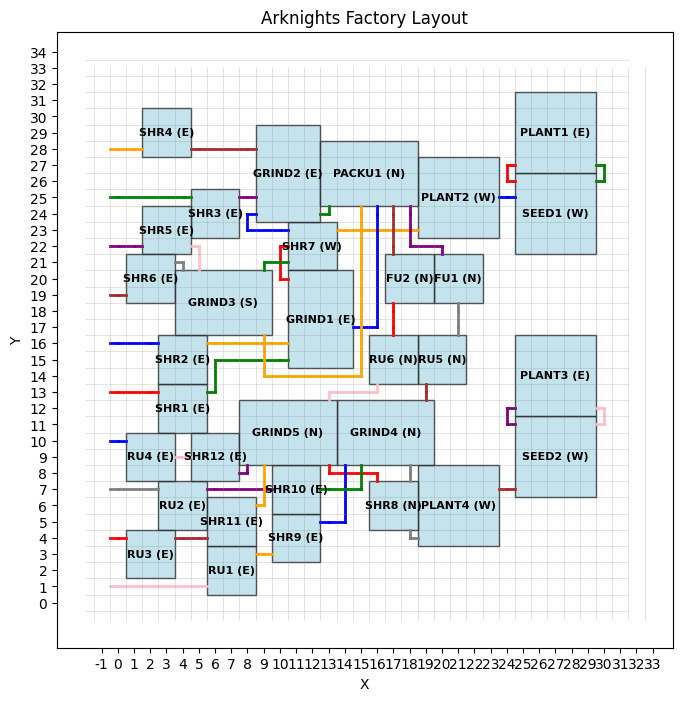

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

# Plot buildings
for name in data.building_x:
    x = data.building_x[name]
    y = data.building_y[name]
    d = data.building_orientation[name][0]
    w, h = building_shapes(name)
    if d in "EW":
        w, h = h, w
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor='lightblue', alpha=0.7)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, f"{name} ({d})", ha='center', va='center', fontsize=8, weight='bold')

# Plot conveyors
for i in range(len(data.conveyor_segment_start_x)):
    # Line extension in the opposite direction for first segment
    sx = data.conveyor_segment_start_x[i][0] + 0.5
    sy = data.conveyor_segment_start_y[i][0] + 0.5
    dx = {"EAST": -0.5, "WEST": 0.5}.get(data.conveyor_orientation[i][0], 0)
    dy = {"NORTH": -0.5, "SOUTH": 0.5}.get(data.conveyor_orientation[i][0], 0)
    ax.plot([sx, sx + dx], [sy, sy + dy], colors[i % len(colors)], linewidth=2)
    # Line extension in the same direction of last segment
    sx = data.conveyor_segment_end_x[i][-1] + 0.5
    sy = data.conveyor_segment_end_y[i][-1] + 0.5
    end_dir = data.building_orientation[CONVEYOR_JOINS[i][1]]
    dx = {"EAST": 0.5, "WEST": -0.5}.get(end_dir, 0)
    dy = {"NORTH": 0.5, "SOUTH": -0.5}.get(end_dir, 0)
    print([sx, sx + dx], [sy, sy + dy])
    ax.plot([sx, sx + dx], [sy, sy + dy], colors[i % len(colors)], linewidth=2)
    for j in range(len(data.conveyor_segment_start_x[i])):
        sx = data.conveyor_segment_start_x[i][j]
        sy = data.conveyor_segment_start_y[i][j]
        ex = data.conveyor_segment_end_x[i][j]
        ey = data.conveyor_segment_end_y[i][j]
        ax.plot([sx + 0.5, ex + 0.5], [sy + 0.5, ey + 0.5], colors[i % len(colors)], linewidth=2)

# Set labels and grid
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Arknights Factory Layout')
# ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.autoscale()

xlim = ax.get_xlim()
ylim = ax.get_ylim()
x_ticks = [i + 0.5 for i in range(int(xlim[0]), int(xlim[1]) + 2)]
x_labels = [i for i in range(int(xlim[0]), int(xlim[1]) + 2)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
y_ticks = [i + 0.5 for i in range(int(ylim[0]), int(ylim[1]) + 2)]
y_labels = [i for i in range(int(ylim[0]), int(ylim[1]) + 2)]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
# Grid at integers
ax.vlines(range(int(xlim[0]), int(xlim[1]) + 2), ylim[0], ylim[1], alpha=0.3, color='gray', linewidth=0.5)
ax.hlines(range(int(ylim[0]), int(ylim[1]) + 2), xlim[0], xlim[1], alpha=0.3, color='gray', linewidth=0.5)
plt.show()

In [35]:
data.building_orientation[CONVEYOR_JOINS[i][1]]

'NORTH'

In [36]:
CONVEYOR_JOINS

[(None, 'SHR1'),
 (None, 'SHR2'),
 (None, 'SHR3'),
 (None, 'SHR4'),
 (None, 'SHR5'),
 (None, 'SHR6'),
 (None, 'RU1'),
 (None, 'RU2'),
 (None, 'RU3'),
 (None, 'RU4'),
 ('SHR1', 'GRIND1'),
 ('SHR2', 'GRIND1'),
 ('SHR3', 'GRIND2'),
 ('SHR4', 'GRIND2'),
 ('SHR5', 'GRIND3'),
 ('SHR6', 'GRIND3'),
 ('SEED1', 'PLANT1'),
 ('SEED1', 'PLANT2'),
 ('PLANT1', 'SEED1'),
 ('PLANT2', 'SHR7'),
 ('SEED2', 'PLANT3'),
 ('SEED2', 'PLANT4'),
 ('PLANT3', 'SEED2'),
 ('PLANT4', 'SHR8'),
 ('SHR7', 'GRIND1'),
 ('SHR7', 'GRIND2'),
 ('SHR7', 'GRIND3'),
 ('RU1', 'SHR9'),
 ('RU2', 'SHR10'),
 ('RU3', 'SHR11'),
 ('RU4', 'SHR12'),
 ('SHR8', 'GRIND4'),
 ('SHR8', 'GRIND5'),
 ('SHR9', 'GRIND4'),
 ('SHR10', 'GRIND4'),
 ('SHR11', 'GRIND5'),
 ('SHR12', 'GRIND5'),
 ('GRIND4', 'RU5'),
 ('GRIND5', 'RU6'),
 ('RU5', 'FU1'),
 ('RU6', 'FU2'),
 ('GRIND1', 'PACKU1'),
 ('GRIND2', 'PACKU1'),
 ('GRIND3', 'PACKU1'),
 ('FU1', 'PACKU1'),
 ('FU2', 'PACKU1')]